# Analysis Notebook

## Import Libraries

In [1]:
import pandas as pd 
import numpy as np
import os 
import matplotlib.pyplot as plt 

PROCESSED_DIR = "../data/processed"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

## Load Processed Master CSV Files

In [2]:
master = pd.read_csv(f"{PROCESSED_DIR}/master_student_program.csv")
daily_master = pd.read_csv(f"{PROCESSED_DIR}/daily_master.csv")
program_metrics = pd.read_csv(f"{PROCESSED_DIR}/program_metrics.csv")

In [3]:
print("Master shape:", master.shape)
print("Daily master shape:", daily_master.shape)
print("Program metrics shape:", program_metrics.shape)

display(master.head())
display(program_metrics.head())

Master shape: (372, 69)
Daily master shape: (7440, 35)
Program metrics shape: (8, 7)


,application_id,user_id,program_id,application_date,motivation_score,cv_score,technical_score,diversity_score,preferred_program_track,preferred_timeslot,selected,waitlisted,final_status,role,country,timezone,gender,education_level,field_of_study,years_experience,prior_neuromatch,preferred_language,interest_area,availability_slot,program_name,year,start_date,end_date,num_students,num_tas,region_focus,curriculum_hours_per_day,project_hours_per_day,total_hours_per_day,days_per_week,delivery_mode,num_timeslots,total_days,attended_curriculum_days,attended_project_days,total_curriculum_hours,total_project_hours,total_zoom_minutes,assignments_completed_total,forum_messages_total,help_requests_total,attendance_rate_curriculum,attendance_rate_project,avg_zoom_minutes_per_day,avg_forum_messages_per_day,avg_help_requests_per_day,post_score,pre_score,mid_score,learning_gain,avg_satisfaction,avg_difficulty,avg_content_quality,avg_ta_support,survey_response_count,dropout_day,reason,dropped_out,support_ticket_count,avg_support_response_time,avg_support_satisfaction,completion_status,engagement_score,survey_response_rate
0,A000002,U00002,P002,2026-03-01,67.661960,60.104138,68.089247,88,Research,Slot 4,1,0,accepted,student,Canada,UTC-5,Male,Masters,Neuro,2,0,English,CV,Slot 4,Deep Learning,2025,2025-06-22,2025-07-24,206,23,global,4.5,3,8,5,virtual,5,20,16,16,66.23,39.53,3792,16,100,27,0.80,0.80,189.60,5.0,1.35,66.0,48.0,NaN,18.0,4.0,4.0,5.0,4.0,1,NaN,NaN,0,NaN,NaN,NaN,1,1.0,0.333333
1,A000006,U00007,P004,2026-03-01,84.445828,44.577177,100.000000,54,Research,Slot 3,1,0,accepted,student,USA,UTC-5,Female,Masters,Climate,8,0,French,CV,Slot 3,NeuroAI,2025,2025-06-22,2025-07-24,235,18,global,4.5,3,8,5,virtual,5,20,17,17,61.21,36.22,3653,17,82,18,0.85,0.85,182.65,4.1,0.90,52.0,47.0,NaN,5.0,5.0,2.0,4.0,3.0,1,NaN,NaN,0,NaN,NaN,NaN,1,1.0,0.333333
2,A000007,U00008,P007,2026-03-01,50.724878,51.085213,99.826941,86,Research,Slot 2,1,0,accepted,student,UK,UTC+0,Male,PhD,Neuro,9,0,English,Climate,Slot 2,Computational Tools for Climate Science,2026,2026-06-22,2026-07-24,208,15,global,4.5,3,8,5,virtual,5,20,13,13,67.41,39.24,3364,13,108,31,0.65,0.65,168.20,5.4,1.55,96.0,66.0,NaN,30.0,5.0,3.0,4.0,3.0,1,NaN,NaN,0,NaN,NaN,NaN,0,1.0,0.333333
3,A000011,U00014,P006,2026-03-01,55.956026,54.914295,100.000000,49,Research,Slot 2,1,0,accepted,student,Brazil,UTC-3,Non-binary,Masters,CS,6,0,English,Neural Coding,Slot 2,Deep Learning,2026,2026-06-22,2026-07-24,351,28,global,4.5,3,8,5,virtual,5,20,15,15,62.47,41.65,4111,15,106,41,0.75,0.75,205.55,5.3,2.05,61.0,53.0,NaN,8.0,3.0,2.0,4.0,4.0,1,NaN,NaN,0,NaN,NaN,NaN,1,1.0,0.333333
4,A000013,U00016,P003,2026-03-01,55.969240,69.915533,78.250660,45,Research,Slot 5,1,0,accepted,student,Japan,UTC+9,Non-binary,Masters,CS,7,0,English,Time Series,Slot 5,Computational Tools for Climate Science,2025,2025-06-22,2025-07-24,262,22,global,4.5,3,8,5,virtual,5,20,16,16,66.95,40.89,3111,16,116,24,0.80,0.80,155.55,5.8,1.20,81.0,63.0,NaN,18.0,3.0,2.0,4.0,4.0,1,NaN,NaN,0,NaN,NaN,NaN,1,1.0,0.333333


,program_id,year,completion_rate,avg_learning_gain,avg_satisfaction,dropout_rate,engagement_score
0,P001,2025,92.68,17.29,4.05,9.76,100.0
1,P002,2025,94.12,16.35,3.84,9.80,100.0
2,P003,2025,89.19,13.76,4.00,5.41,100.0
3,P004,2025,83.33,16.59,3.87,12.96,100.0
4,P005,2026,88.24,18.18,4.00,11.76,100.0


## APPLICATION / ENROLLMENT / PROGRAM OVERVIEW

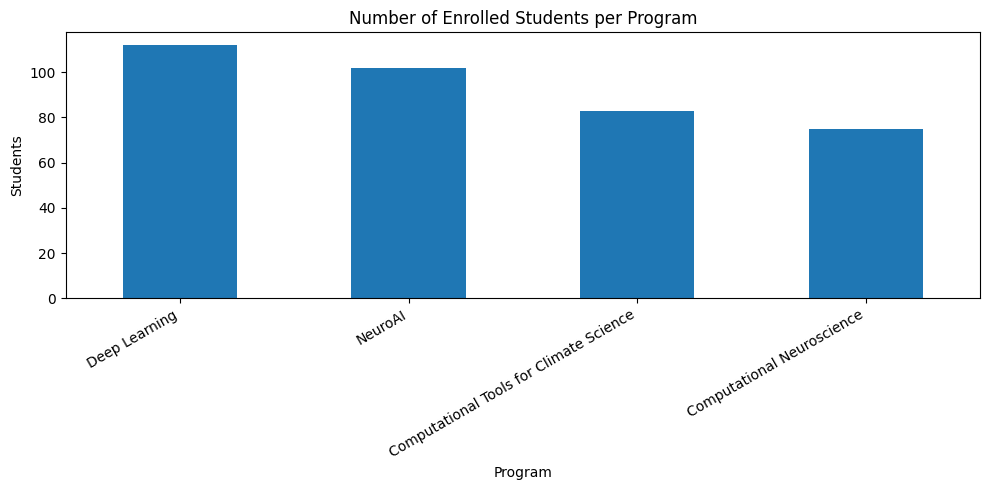

In [4]:
students_per_program = master.groupby("program_name")["user_id"].nunique().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
students_per_program.plot(kind="bar")
plt.title("Number of Enrolled Students per Program")
plt.ylabel("Students")
plt.xlabel("Program")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

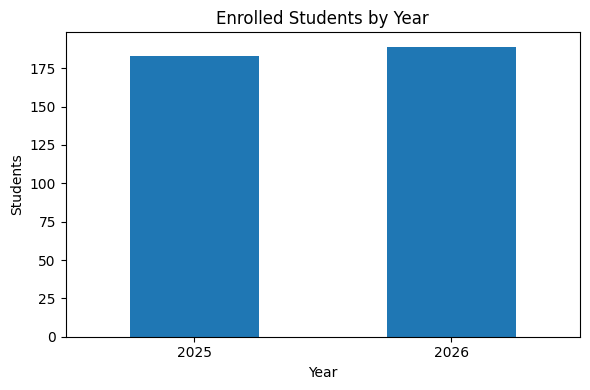

In [5]:
students_per_year = master.groupby("year")["user_id"].nunique()

plt.figure(figsize=(6, 4))
students_per_year.plot(kind="bar")
plt.title("Enrolled Students by Year")
plt.ylabel("Students")
plt.xlabel("Year")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## ENGAGEMENT ANALYSIS

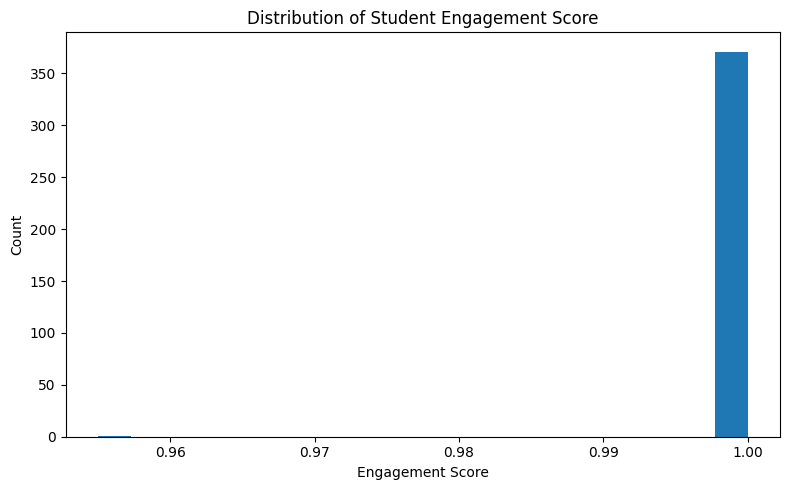

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(master["engagement_score"].dropna(), bins=20)
plt.title("Distribution of Student Engagement Score")
plt.xlabel("Engagement Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

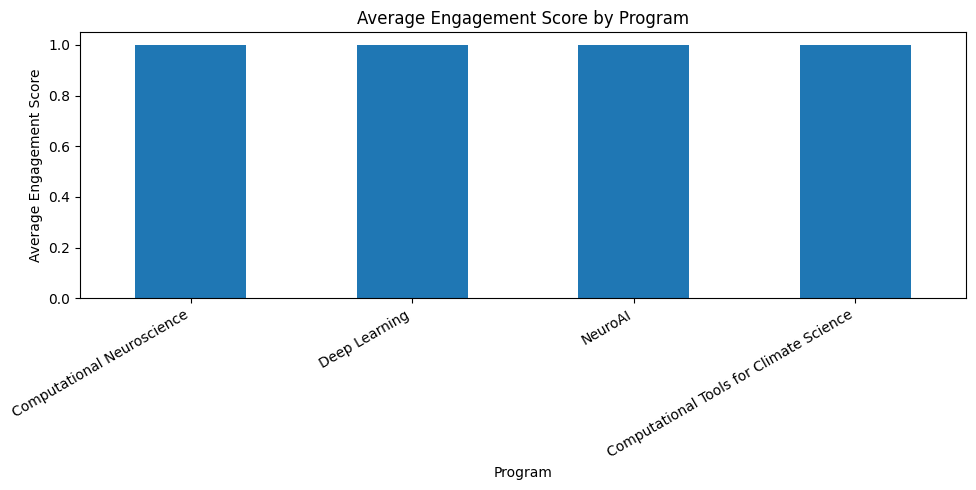

In [7]:
engagement_by_program = master.groupby("program_name")["engagement_score"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
engagement_by_program.plot(kind="bar")
plt.title("Average Engagement Score by Program")
plt.ylabel("Average Engagement Score")
plt.xlabel("Program")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [8]:
attendance_completion = master.groupby("completion_status")[["attendance_rate_curriculum", "attendance_rate_project"]].mean()

attendance_completion

,attendance_rate_curriculum,attendance_rate_project
completion_status,,
0,0.631250,0.631250
1,0.816114,0.816114


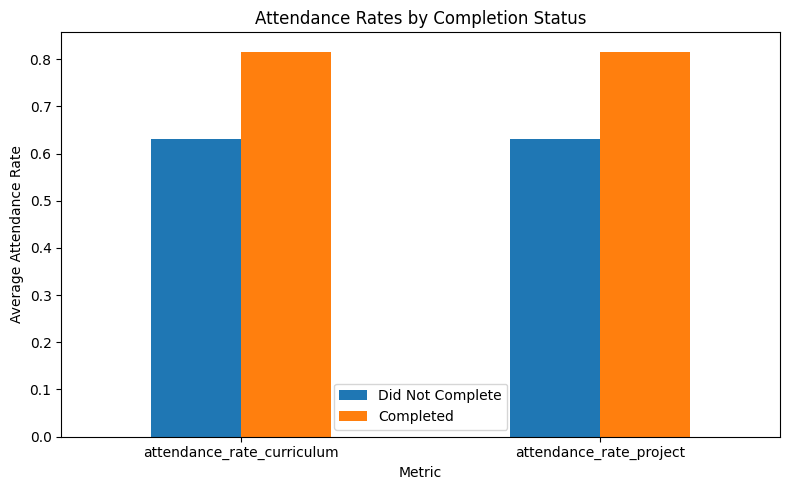

In [9]:
attendance_completion.T.plot(kind="bar", figsize=(8, 5))
plt.title("Attendance Rates by Completion Status")
plt.ylabel("Average Attendance Rate")
plt.xlabel("Metric")
plt.xticks(rotation=0)
plt.legend(["Did Not Complete", "Completed"])
plt.tight_layout()
plt.show()

## LEARNING OUTCOMES

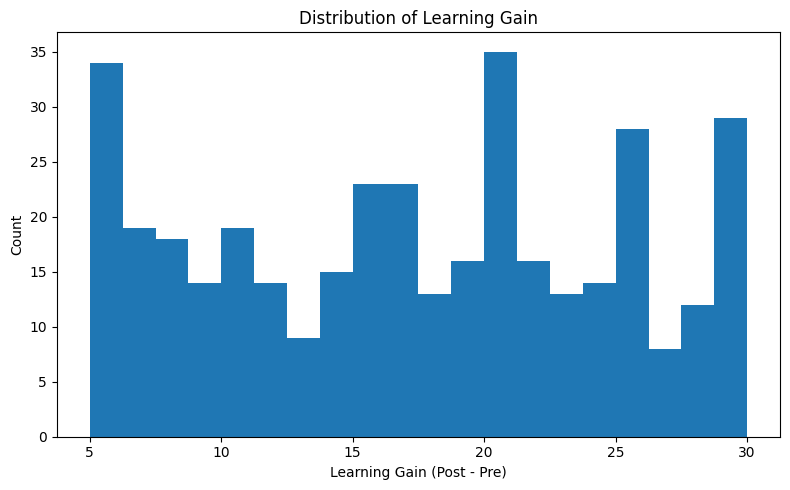

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(master["learning_gain"].dropna(), bins=20)
plt.title("Distribution of Learning Gain")
plt.xlabel("Learning Gain (Post - Pre)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

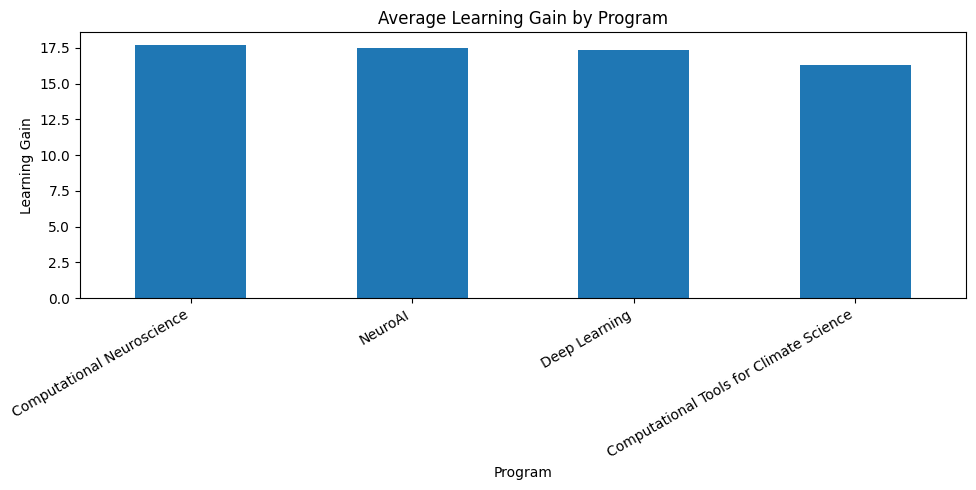

In [11]:
learning_gain_by_program = master.groupby("program_name")["learning_gain"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
learning_gain_by_program.plot(kind="bar")
plt.title("Average Learning Gain by Program")
plt.ylabel("Learning Gain")
plt.xlabel("Program")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

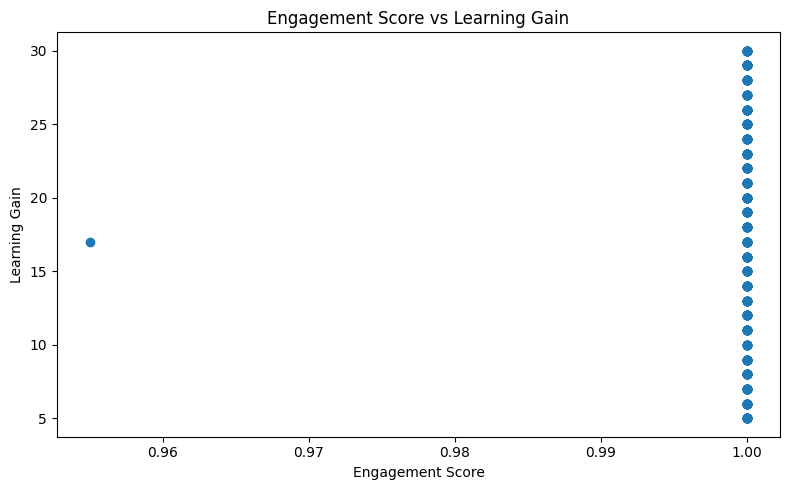

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(master["engagement_score"], master["learning_gain"])
plt.title("Engagement Score vs Learning Gain")
plt.xlabel("Engagement Score")
plt.ylabel("Learning Gain")
plt.tight_layout()
plt.show()

## STUDENT EXPERIENCE / SATISFACTION

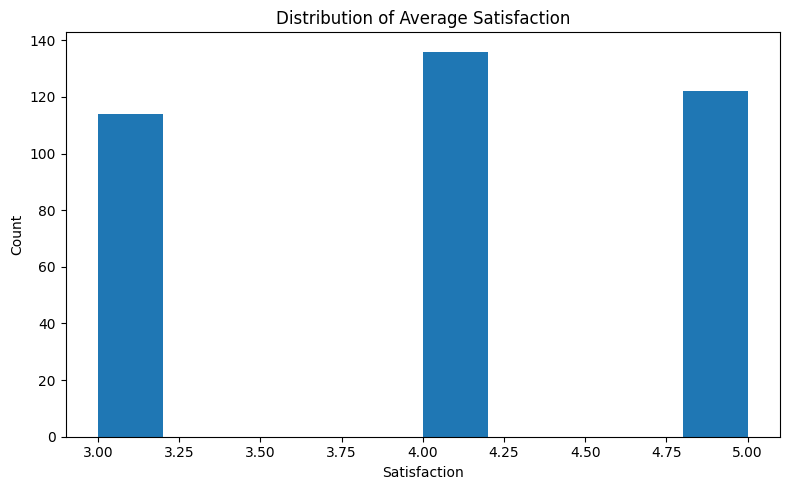

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(master["avg_satisfaction"].dropna(), bins=10)
plt.title("Distribution of Average Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

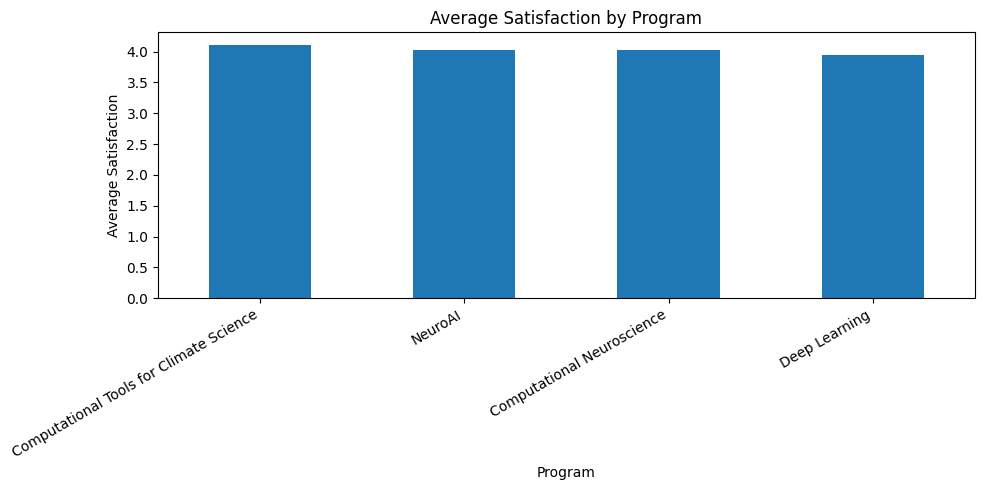

In [14]:
satisfaction_by_program = master.groupby("program_name")["avg_satisfaction"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
satisfaction_by_program.plot(kind="bar")
plt.title("Average Satisfaction by Program")
plt.ylabel("Average Satisfaction")
plt.xlabel("Program")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

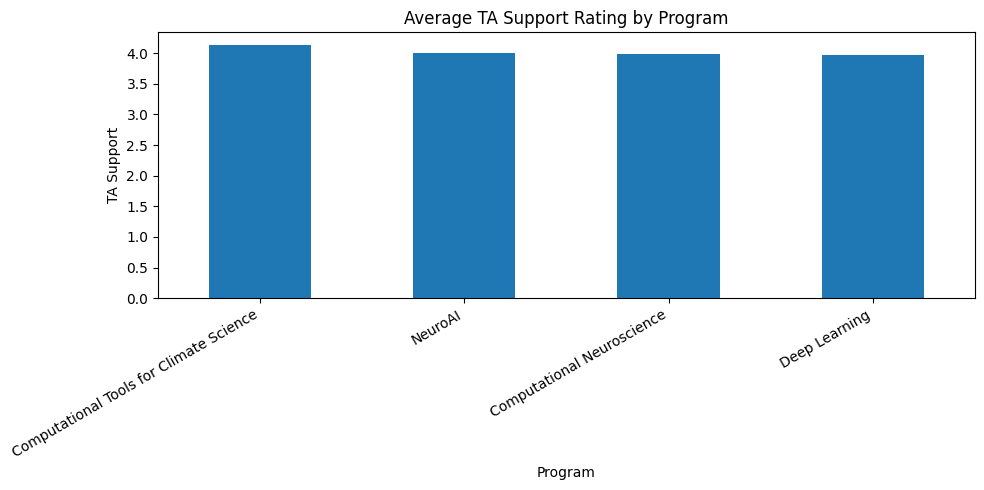

In [15]:
ta_support_by_program = master.groupby("program_name")["avg_ta_support"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
ta_support_by_program.plot(kind="bar")
plt.title("Average TA Support Rating by Program")
plt.ylabel("TA Support")
plt.xlabel("Program")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## DROPOUT ANALYSIS

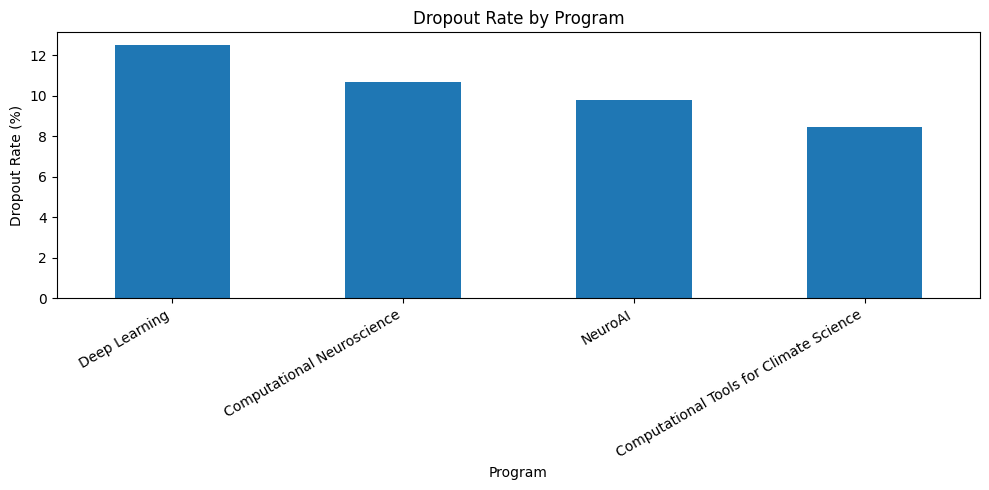

In [16]:
dropout_by_program = master.groupby("program_name")["dropped_out"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))
dropout_by_program.plot(kind="bar")
plt.title("Dropout Rate by Program")
plt.ylabel("Dropout Rate (%)")
plt.xlabel("Program")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

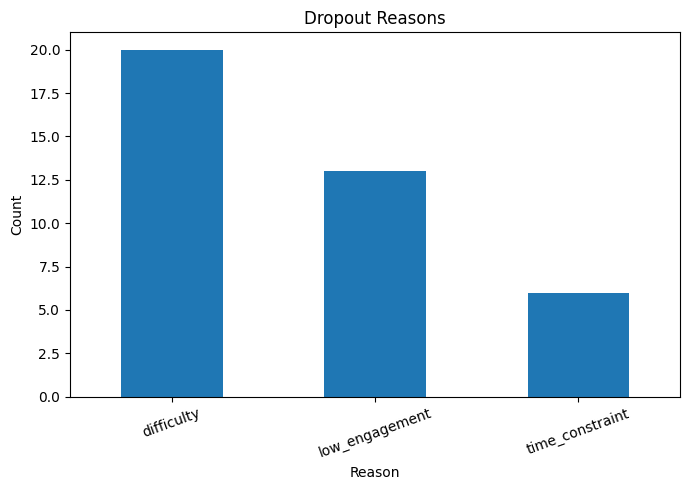

In [17]:
dropout_reasons = master["reason"].value_counts(dropna=True)

plt.figure(figsize=(7, 5))
dropout_reasons.plot(kind="bar")
plt.title("Dropout Reasons")
plt.ylabel("Count")
plt.xlabel("Reason")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [18]:
dropout_engagement = master.groupby("dropped_out")["engagement_score"].mean()
dropout_engagement

dropped_out
0    0.999865
1    1.000000
Name: engagement_score, dtype: float64

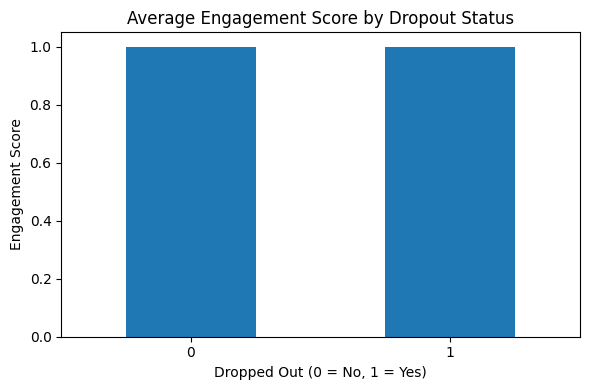

In [19]:
dropout_engagement.plot(kind="bar", figsize=(6, 4))
plt.title("Average Engagement Score by Dropout Status")
plt.ylabel("Engagement Score")
plt.xlabel("Dropped Out (0 = No, 1 = Yes)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## DIVERSITY / COHORT ANALYSIS

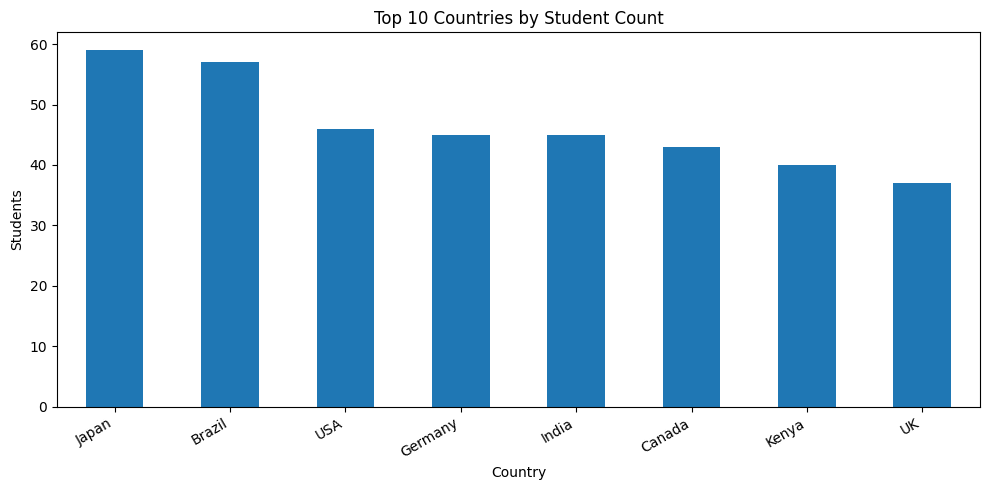

In [20]:
country_counts = master["country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
country_counts.plot(kind="bar")
plt.title("Top 10 Countries by Student Count")
plt.ylabel("Students")
plt.xlabel("Country")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

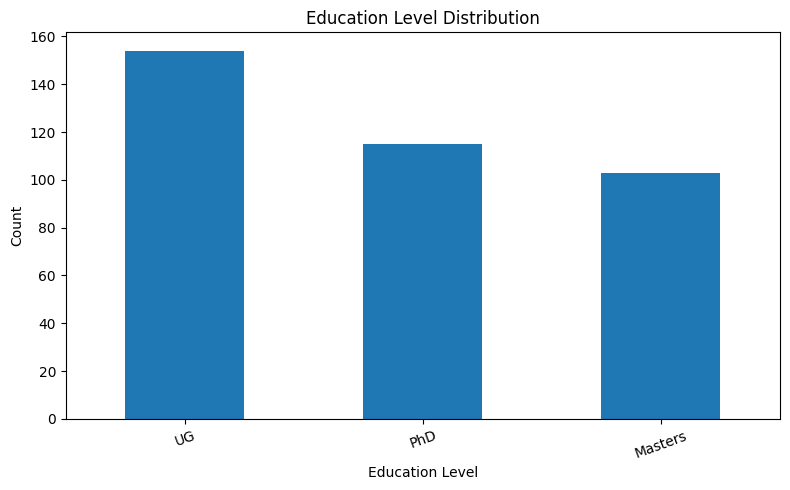

In [21]:
edu_counts = master["education_level"].value_counts()

plt.figure(figsize=(8, 5))
edu_counts.plot(kind="bar")
plt.title("Education Level Distribution")
plt.ylabel("Count")
plt.xlabel("Education Level")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [22]:
prior_nm_completion = master.groupby("prior_neuromatch")["completion_status"].mean() * 100
prior_nm_completion

prior_neuromatch
0    88.513514
1    92.105263
Name: completion_status, dtype: float64

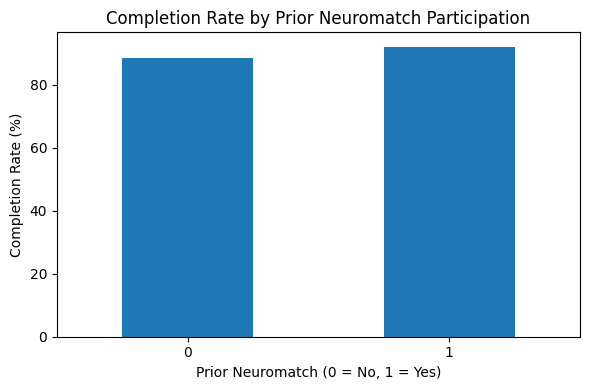

In [23]:
prior_nm_completion.plot(kind="bar", figsize=(6, 4))
plt.title("Completion Rate by Prior Neuromatch Participation")
plt.ylabel("Completion Rate (%)")
plt.xlabel("Prior Neuromatch (0 = No, 1 = Yes)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## PROGRAM METRICS DASHBOARD VIEW

In [24]:
program_metrics.sort_values(["year", "completion_rate"], ascending=[True, False])

,program_id,year,completion_rate,avg_learning_gain,avg_satisfaction,dropout_rate,engagement_score
1,P002,2025,94.12,16.35,3.84,9.80,100.0
0,P001,2025,92.68,17.29,4.05,9.76,100.0
2,P003,2025,89.19,13.76,4.00,5.41,100.0
3,P004,2025,83.33,16.59,3.87,12.96,100.0
7,P008,2026,91.67,18.48,4.21,6.25,100.0
5,P006,2026,88.52,18.15,4.03,14.75,100.0
4,P005,2026,88.24,18.18,4.00,11.76,100.0
6,P007,2026,86.96,18.39,4.20,10.87,99.9


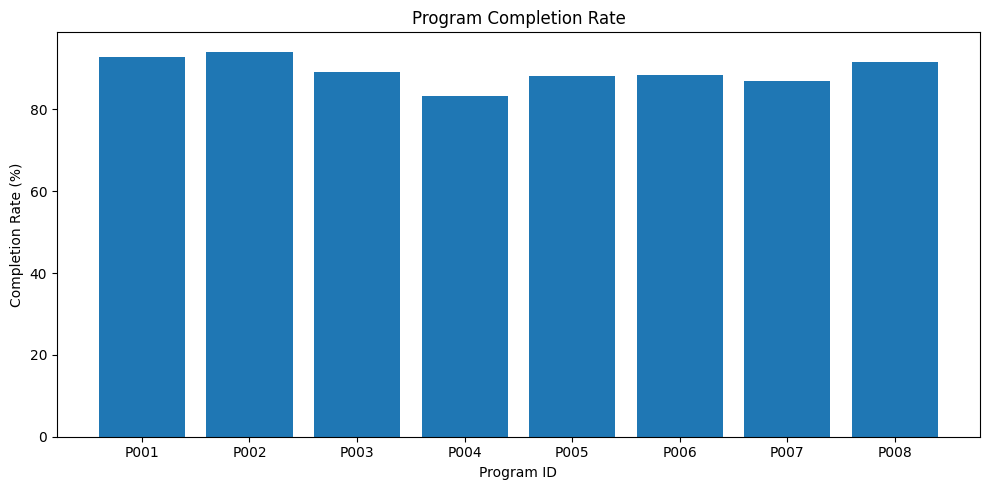

In [25]:
plt.figure(figsize=(10, 5))
plt.bar(program_metrics["program_id"], program_metrics["completion_rate"])
plt.title("Program Completion Rate")
plt.ylabel("Completion Rate (%)")
plt.xlabel("Program ID")
plt.tight_layout()
plt.show()

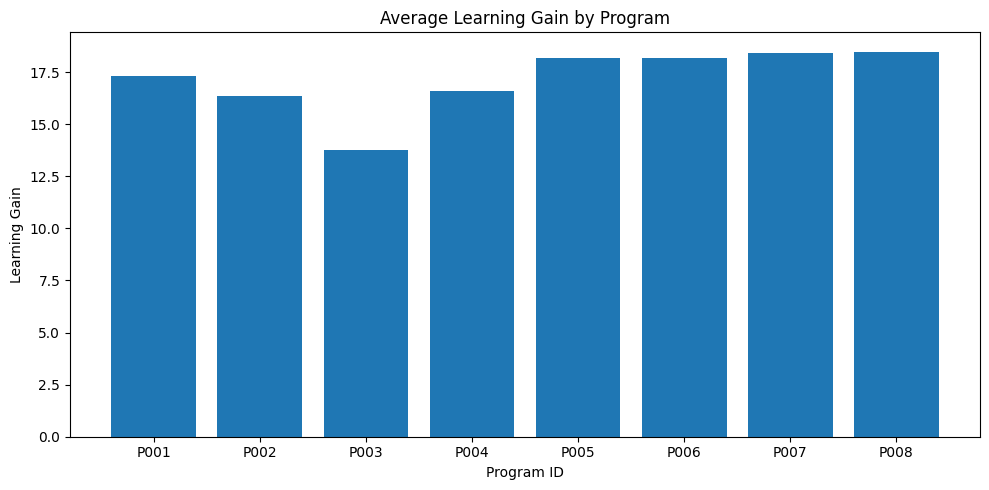

In [26]:
plt.figure(figsize=(10, 5))
plt.bar(program_metrics["program_id"], program_metrics["avg_learning_gain"])
plt.title("Average Learning Gain by Program")
plt.ylabel("Learning Gain")
plt.xlabel("Program ID")
plt.tight_layout()
plt.show()

## CORRELATION CHECK

In [27]:
corr_cols = [
    "engagement_score",
    "attendance_rate_curriculum",
    "attendance_rate_project",
    "learning_gain",
    "avg_satisfaction",
    "avg_ta_support",
    "dropped_out",
    "completion_status"
]

master[corr_cols].corr()

,engagement_score,attendance_rate_curriculum,attendance_rate_project,learning_gain,avg_satisfaction,avg_ta_support,dropped_out,completion_status
engagement_score,1.000000,0.082972,0.082972,0.001516,-0.063804,-0.059478,0.017767,0.149573
attendance_rate_curriculum,0.082972,1.000000,1.000000,0.014236,-0.074528,0.021485,-0.057848,0.625851
attendance_rate_project,0.082972,1.000000,1.000000,0.014236,-0.074528,0.021485,-0.057848,0.625851
learning_gain,0.001516,0.014236,0.014236,1.000000,0.080597,-0.045954,-0.005342,-0.003658
avg_satisfaction,-0.063804,-0.074528,-0.074528,0.080597,1.000000,0.034885,0.034840,-0.045118
avg_ta_support,-0.059478,0.021485,0.021485,-0.045954,0.034885,1.000000,-0.120221,-0.022770
dropped_out,0.017767,-0.057848,-0.057848,-0.005342,0.034840,-0.120221,1.000000,0.005483
completion_status,0.149573,0.625851,0.625851,-0.003658,-0.045118,-0.022770,0.005483,1.000000


In [28]:
summary = {
    "Total Enrolled Students": master["user_id"].nunique(),
    "Avg Engagement Score": round(master["engagement_score"].mean(), 3),
    "Avg Learning Gain": round(master["learning_gain"].mean(), 2),
    "Avg Satisfaction": round(master["avg_satisfaction"].mean(), 2),
    "Completion Rate (%)": round(master["completion_status"].mean() * 100, 2),
    "Dropout Rate (%)": round(master["dropped_out"].mean() * 100, 2)
}

pd.DataFrame(summary.items(), columns=["Metric", "Value"])

,Metric,Value
0,Total Enrolled Students,372.00
1,Avg Engagement Score,1.00
2,Avg Learning Gain,17.22
3,Avg Satisfaction,4.02
4,Completion Rate (%),89.25
5,Dropout Rate (%),10.48
